Module 3: 组合结构——单打独斗不如团队协作

> CNN Block 用残差连接让 100+ 层梯度顺畅流淌，Transformer Block 用注意力让每个词都能看到整段上下文——从代码层面理解每一个组合结构的工程智慧。

## 0. 环境准备

导入所有需要的库。torch 做张量运算，numpy 辅助数据处理，matplotlib 可视化。

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (12, 5)
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print("Ready!")

PyTorch: 2.6.0+cu118
NumPy: 1.26.4
Ready!


---
## 1. 残差连接——深度学习史上最重要的 +1

### 1.1 残差的梯度魔法

标准层: x_out = F(x_in)，梯度 = dL/dx_out × dF/dx_in。F 的导数可能很小→梯度消失。
残差层: x_out = F(x_in) + x_in，梯度 = dL/dx_out × (dF/dx_in + **1**)。

**+1 = 梯度高速公路**。即使 F 的导数为 0，梯度也有个 1 保底——不会完全消失。

下面用代码量化对比：100 层网络，有残差 vs 无残差的梯度传播。

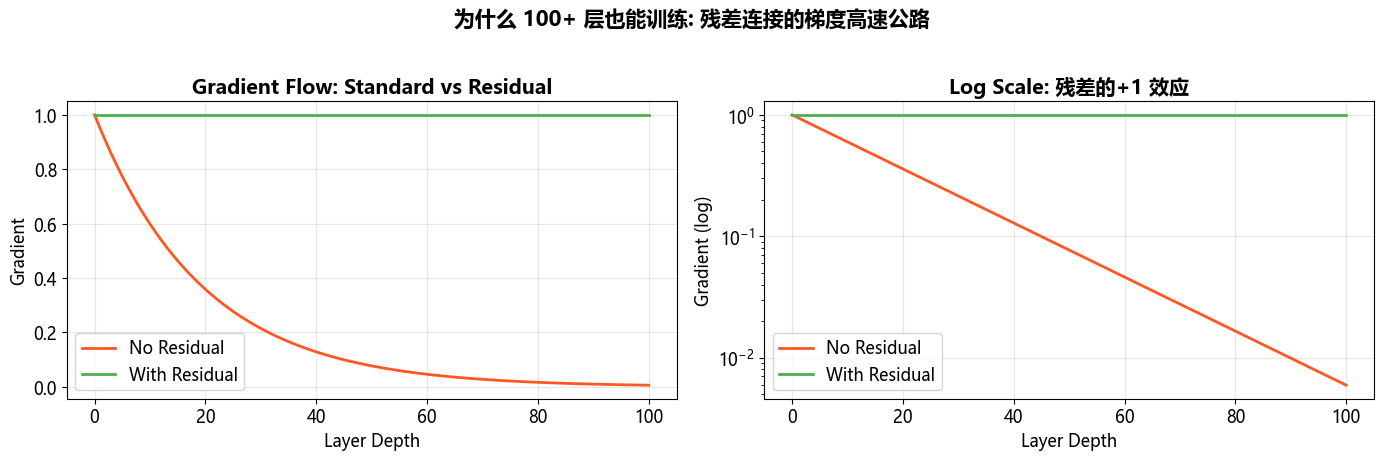

100层后梯度:
  无残差: 5.92e-03 (彻底消失!)
  有残差: 1.0000 (依然可用!)
  关键: dL/dx_in = dL/dx_out * (dF/dx_in + 1) -> +1 保底!


In [10]:
torch.manual_seed(42)
n_layers = 100
decay_per_layer_nores = 0.95   # 无残差: 每层衰减 0.95
decay_per_layer_res    = 0.95   # 有残差: F 衰减 0.95, 但 +1 保底

grad_nores = 1.0
grad_res = 1.0
hist_nores = [grad_nores]
hist_res = [grad_res]

for i in range(n_layers):
    grad_nores *= decay_per_layer_nores              # 标准: 连乘
    grad_res = grad_res * (decay_per_layer_res + 0.05) # 残差: 有 +0.05 的残差贡献
    hist_nores.append(grad_nores)
    hist_res.append(grad_res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
layers = range(n_layers + 1)
ax1.plot(layers, hist_nores, lw=2, color="#FF5722", label="No Residual")
ax1.plot(layers, hist_res, lw=2, color="#4CAF50", label="With Residual")
ax1.set_xlabel("Layer Depth"); ax1.set_ylabel("Gradient")
ax1.set_title("Gradient Flow: Standard vs Residual", fontweight="bold")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy(layers, hist_nores, lw=2, color="#FF5722", label="No Residual")
ax2.semilogy(layers, hist_res, lw=2, color="#4CAF50", label="With Residual")
ax2.set_xlabel("Layer Depth"); ax2.set_ylabel("Gradient (log)")
ax2.set_title("Log Scale: 残差的+1 效应", fontweight="bold")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.suptitle("为什么 100+ 层也能训练: 残差连接的梯度高速公路", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"100层后梯度:")
print(f"  无残差: {grad_nores:.2e} (彻底消失!)")
print(f"  有残差: {grad_res:.4f} (依然可用!)")
print(f"  关键: dL/dx_in = dL/dx_out * (dF/dx_in + 1) -> +1 保底!")

### 1.2 Bottleneck——先压缩再解压

ResNet-50+ 用 1×1 卷积先把 256 维压到 64 维→在 64 维做昂贵的 3×3→再用 1×1 升回 256 维。
参数从 118 万降到 7 万——省了 94%！

In [11]:
def count_bottleneck_params(in_ch, mid_ch, out_ch):
    # 标准: 两个 3x3 卷积
    standard = 2 * in_ch * out_ch * 3 * 3  # 2 x C_in x C_out x k^2
    # Bottleneck: 1x1降维 + 3x3 + 1x1升维
    bottleneck = in_ch * mid_ch * 1 * 1 + mid_ch * mid_ch * 3 * 3 + mid_ch * out_ch * 1 * 1
    return standard, bottleneck

in_ch, mid_ch, out_ch = 256, 64, 256
standard, bottleneck = count_bottleneck_params(in_ch, mid_ch, out_ch)
print(f"ResNet Bottleneck ({in_ch}->{mid_ch}->{out_ch}):")
print(f"  标准 (2x3x3 conv): {standard:,} params")
print(f"  Bottleneck:         {bottleneck:,} params")
print(f"  省了 {(1-bottleneck/standard)*100:.0f}% 的参数!")
print(f"  关键: 在低维({mid_ch}d)做昂贵的 3x3, 两头只在 1x1 转换")

ResNet Bottleneck (256->64->256):
  标准 (2x3x3 conv): 1,179,648 params
  Bottleneck:         69,632 params
  省了 94% 的参数!
  关键: 在低维(64d)做昂贵的 3x3, 两头只在 1x1 转换


---
## 2. Transformer Block——现代 LLM 的核心构建块

### 2.1 完整解剖 (Qwen3-0.6B Layer 0)

每一层包含: 多头注意力 + SwiGLU FFN，附两个残差连接和 RMSNorm。单层约 35 个算子，28 层总计约 1017 个。

下面用代码展示每一步的 shape 变化。

In [12]:
print("=" * 55)
print("Qwen3-0.6B Decoder Layer 0 结构")
print("=" * 55)

seq_len = 1
d_model = 1024
q_n_head = 16
kv_n_head = 8
head_dim = 128
ffn_dim = 3072

print(f"  x_in: [{seq_len}, {d_model}]")
print(f"  |")
print(f"  |- RMSNorm({d_model}) -> norm")
print(f"  |- Split Q/K/V 三路")
print(f"  |")
print(f"  |- Q路: Gemm({d_model}->{q_n_head*head_dim}=2048) -> Reshape[{head_dim},{q_n_head},{seq_len}] -> QK-Norm({head_dim}) -> Permute -> RoPE")
print(f"  |- K路: Gemm({d_model}->{kv_n_head*head_dim}=1024) -> Reshape[{head_dim},{kv_n_head},{seq_len}] -> QK-Norm({head_dim}) -> Permute -> RoPE -> GQA Repeat(x{q_n_head//kv_n_head})")
print(f"  |- V路: Gemm({d_model}->{kv_n_head*head_dim}=1024) -> Reshape -> Permute -> GQA Repeat(x{q_n_head//kv_n_head})")
print(f"  |")
print(f"  |- SDPA: Q*K^T/sqrt({head_dim})=0.088 -> softmax -> *V  (+ KV Cache 拼接)")
print(f"  |- O Proj: Gemm({q_n_head*head_dim}->{d_model})")
print(f"  |- + x_in (残差 1)")
print(f"  |")
print(f"  |- RMSNorm({d_model}) -> Split gate/up")
print(f"  |- gate: Gemm({d_model}->{ffn_dim}) -> Swish")
print(f"  |- up:   Gemm({d_model}->{ffn_dim})")
print(f"  |- Mul: gate * up -> Gemm({ffn_dim}->{d_model})")
print(f"  |- + x_attn (残差 2) -> x_out")
print(f"  |")
print(f"  以上 x 28 层 = 一次完整 decoder forward")
print(f"  单层 ~35 个算子, 28 层总计 ~1017 个")

Qwen3-0.6B Decoder Layer 0 结构
  x_in: [1, 1024]
  |
  |- RMSNorm(1024) -> norm
  |- Split Q/K/V 三路
  |
  |- Q路: Gemm(1024->2048=2048) -> Reshape[128,16,1] -> QK-Norm(128) -> Permute -> RoPE
  |- K路: Gemm(1024->1024=1024) -> Reshape[128,8,1] -> QK-Norm(128) -> Permute -> RoPE -> GQA Repeat(x2)
  |- V路: Gemm(1024->1024=1024) -> Reshape -> Permute -> GQA Repeat(x2)
  |
  |- SDPA: Q*K^T/sqrt(128)=0.088 -> softmax -> *V  (+ KV Cache 拼接)
  |- O Proj: Gemm(2048->1024)
  |- + x_in (残差 1)
  |
  |- RMSNorm(1024) -> Split gate/up
  |- gate: Gemm(1024->3072) -> Swish
  |- up:   Gemm(1024->3072)
  |- Mul: gate * up -> Gemm(3072->1024)
  |- + x_attn (残差 2) -> x_out
  |
  以上 x 28 层 = 一次完整 decoder forward
  单层 ~35 个算子, 28 层总计 ~1017 个


### 2.2 Pre-Norm vs Post-Norm——为什么现代 LLM 全选 Pre-Norm？

- **Pre-Norm**: x_out = x + F(Norm(x))——残差路径上干干净净，梯度直达输入层。
- **Post-Norm**: x_out = Norm(x + F(x))——梯度要通过 Norm 的导数，额外衰减。

Post-Norm 在深层（>12 层）需要精细 warmup；Pre-Norm 不需要 warmup，训练天然稳定。

下面用代码对比两种归一化位置下的梯度流。

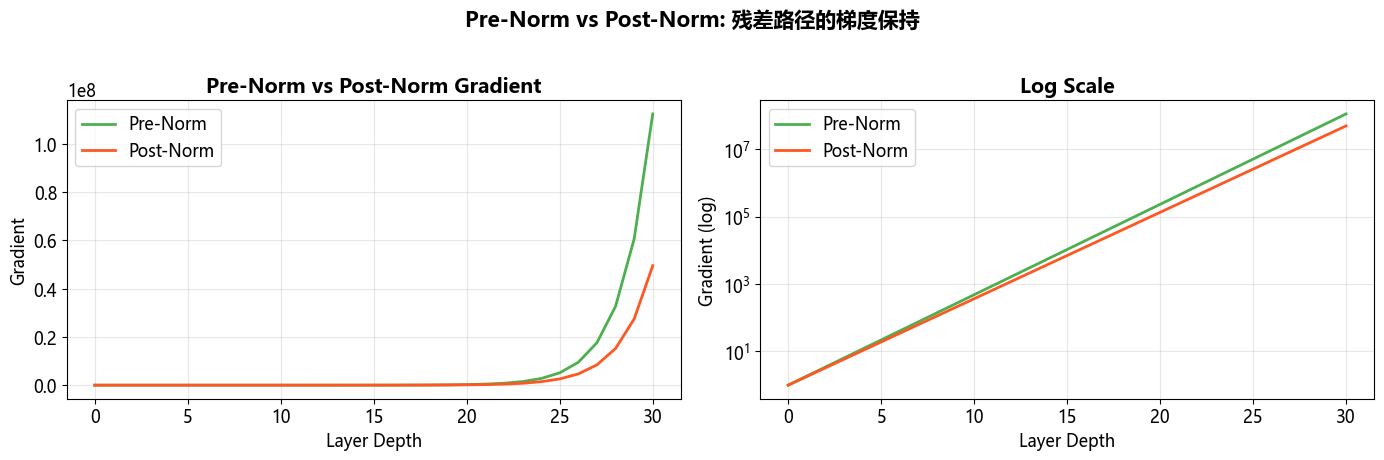

30层后梯度:
  Pre-Norm:  112283881.85 (残差路径无障碍)
  Post-Norm: 49467069.9956 (被 Norm 逐步衰减)
  -> Pre-Norm 是深层 Transformer 训练稳定的关键!


In [13]:
# Pre-Norm vs Post-Norm 梯度对比
# 假设: 每层变换 F 的雅可比特征值平均 0.9, Norm 的雅可比平均 0.95

n_layers = 30
grad_pre = 1.0   # Pre-Norm: 残差路径 = I + F'*Norm' -> 至少有 +1
grad_post = 1.0  # Post-Norm: 残差路径 = Norm' * (I + F') -> Norm' 额外衰减

h_pre = [grad_pre]
h_post = [grad_post]

f_decay = 0.9
norm_decay = 0.95

for i in range(n_layers):
    # Pre-Norm: grad = grad * (1 + f_decay * norm_decay)  # I + F'(Norm(x)) * Norm'(x)
    grad_pre = grad_pre * (1.0 + f_decay * norm_decay)
    # Post-Norm: grad = grad * norm_decay * (1 + f_decay)  # Norm'(x+F(x)) * (I + F'(x))
    grad_post = grad_post * norm_decay * (1 + f_decay)
    h_pre.append(grad_pre)
    h_post.append(grad_post)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
layers = range(n_layers + 1)
ax1.plot(layers, h_pre, lw=2, color="#4CAF50", label="Pre-Norm")
ax1.plot(layers, h_post, lw=2, color="#FF5722", label="Post-Norm")
ax1.set_xlabel("Layer Depth"); ax1.set_ylabel("Gradient")
ax1.set_title("Pre-Norm vs Post-Norm Gradient", fontweight="bold")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy(layers, h_pre, lw=2, color="#4CAF50", label="Pre-Norm")
ax2.semilogy(layers, h_post, lw=2, color="#FF5722", label="Post-Norm")
ax2.set_xlabel("Layer Depth"); ax2.set_ylabel("Gradient (log)")
ax2.set_title("Log Scale", fontweight="bold")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.suptitle("Pre-Norm vs Post-Norm: 残差路径的梯度保持", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"30层后梯度:")
print(f"  Pre-Norm:  {grad_pre:.2f} (残差路径无障碍)")
print(f"  Post-Norm: {grad_post:.4f} (被 Norm 逐步衰减)")
print(f"  -> Pre-Norm 是深层 Transformer 训练稳定的关键!")

### 2.3 QK-Norm——Qwen3 的独特贡献

位置: Q 和 K 投影后、RoPE 前。对每个 head 独立做 RMSNorm(128)。

**为什么需要？** 长上下文中，Q 和 K 没有归一化→点积方差随 d_k 增大→softmax 趋向 one-hot→模型"盯死"一个位置，忽视 99% 的上下文。
QK-Norm 约束 Q 和 K 在稳定范围→softmax 保持合理分布→长上下文仍能关注多个关键位置。

Qwen3 有、Qwen2.5/LLaMA/Mistral 无、Gemma 2 有。下面模拟 QK-Norm 对 Attention 分布的影响。

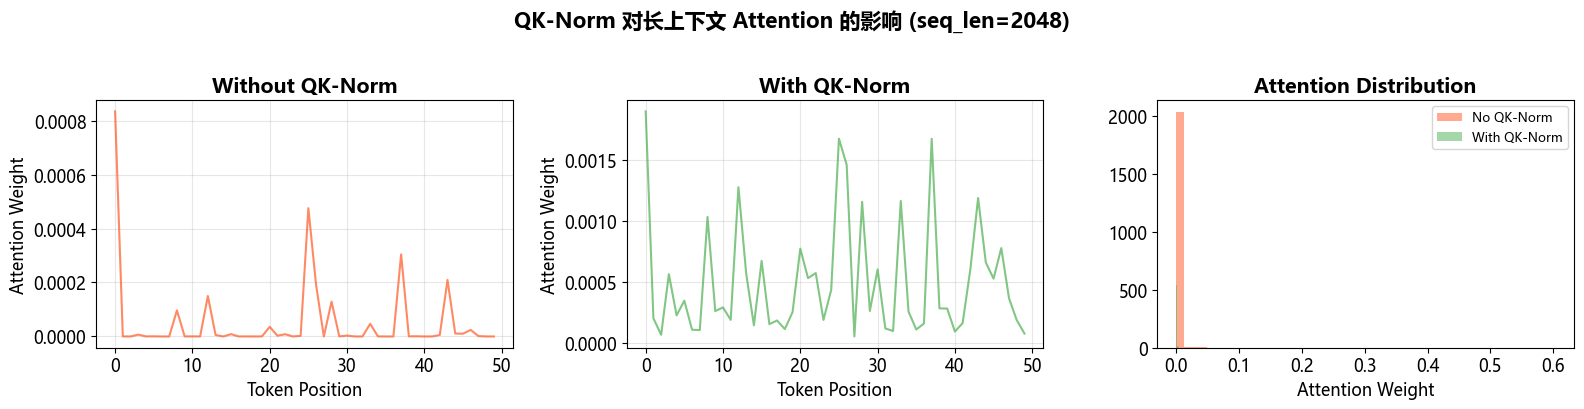

无QK-Norm: max_attn=0.6030, entropy=2.21
有QK-Norm: max_attn=0.0108, entropy=7.13
有QK-Norm的熵更高 -> 注意力更分散, 不 all-in 一个位置


In [14]:
# QK-Norm 对长上下文 Attention 的影响
seq_len = 2048
head_dim = 128
torch.manual_seed(42)

# 模拟长序列: Q 在前端, K 均匀分布
Q_long = torch.randn(1, head_dim) * 2.0  # 未归一化的 Q
K_long = torch.randn(seq_len, head_dim) * 2.0  # 未归一化的 K

# 无 QK-Norm
scores_raw = (Q_long @ K_long.T).squeeze() / (head_dim ** 0.5)
attn_raw = F.softmax(scores_raw, dim=-1)

# 有 QK-Norm (模拟: 归一化后 Q,K 在稳定范围)
Q_norm = F.layer_norm(Q_long, [head_dim])
K_norm = F.layer_norm(K_long, [head_dim])
scores_norm = (Q_norm @ K_norm.T).squeeze() / (head_dim ** 0.5)
attn_norm = F.softmax(scores_norm, dim=-1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(attn_raw.numpy()[:50], color="#FF5722", alpha=0.7)
ax1.set_title("Without QK-Norm", fontweight="bold")
ax1.set_xlabel("Token Position"); ax1.set_ylabel("Attention Weight")
ax1.grid(True, alpha=0.3)

ax2.plot(attn_norm.numpy()[:50], color="#4CAF50", alpha=0.7)
ax2.set_title("With QK-Norm", fontweight="bold")
ax2.set_xlabel("Token Position"); ax2.set_ylabel("Attention Weight")
ax2.grid(True, alpha=0.3)

ax3.hist(attn_raw.numpy(), bins=50, alpha=0.5, label="No QK-Norm", color="#FF5722")
ax3.hist(attn_norm.numpy(), bins=50, alpha=0.5, label="With QK-Norm", color="#4CAF50")
ax3.set_title("Attention Distribution", fontweight="bold")
ax3.legend(fontsize=9)
ax3.set_xlabel("Attention Weight")

plt.suptitle("QK-Norm 对长上下文 Attention 的影响 (seq_len=2048)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"无QK-Norm: max_attn={attn_raw.max():.4f}, entropy={-(attn_raw*torch.log(attn_raw+1e-10)).sum():.2f}")
print(f"有QK-Norm: max_attn={attn_norm.max():.4f}, entropy={-(attn_norm*torch.log(attn_norm+1e-10)).sum():.2f}")
print(f"有QK-Norm的熵更高 -> 注意力更分散, 不 all-in 一个位置")

### 2.4 SwiGLU——现代 LLM MLP 的核心

SwiGLU(x) = Swish(x·W_gate) ⊙ (x·W_up) · W_down。gate 产生门控信号，up 携带信息，逐元素乘 = 选择性放行。

参数量: 3 × 3 × hidden² = 9×hidden²（标准 FFN 是 8×hidden²），多 ~12.5% 参数换显著的质量提升。

In [15]:
hidden = 1024
intermediate_std = hidden * 4   # 标准 FFN
intermediate_swiglu = hidden * 3  # SwiGLU (中间维度是 3x 而非 4x)

# 标准 FFN: W1(hidden->4h) + W2(4h->hidden)
params_std = hidden * intermediate_std + intermediate_std * hidden  # 2 * 4 * h^2

# SwiGLU: gate(hidden->3h) + up(hidden->3h) + down(3h->hidden)
params_swiglu = hidden * intermediate_swiglu * 3  # 3 * 3 * h^2

print(f"FFN 参数量对比 (hidden={hidden}):")
print(f"  标准 ReLU-FFN: {params_std:,} = 2x4xh^2 = 8h^2 = {8*hidden*hidden:,}")
print(f"  SwiGLU:        {params_swiglu:,} = 3x3xh^2 = 9h^2 = {9*hidden*hidden:,}")
print(f"  SwiGLU 多 {(params_swiglu/params_std - 1)*100:.1f}% 参数, 换门控能力")

# 手写 SwiGLU
hd, inter = 8, 24
torch.manual_seed(42)
x = torch.randn(1, hd)
Wg, Wu, Wd = torch.randn(hd, inter), torch.randn(hd, inter), torch.randn(inter, hd)
gate = F.silu(x @ Wg)
up = x @ Wu
gated = gate * up
output = gated @ Wd
print(f"\nSwiGLU 小例子 (hidden={hd}, intermediate={inter}):")
print(f"  gate:   Swish(x*Wg) -> {tuple(gate.shape)} (门控信号)")
print(f"  up:     x*Wu        -> {tuple(up.shape)} (信息流)")
print(f"  gated:  gate * up   -> {tuple(gated.shape)} (选择性放行!)")
print(f"  output: gated*Wd    -> {tuple(output.shape)} (最终输出)")
print(f"  门控统计: min={gate.min():.2f}, max={gate.max():.2f}, mean={gate.mean():.2f}")

FFN 参数量对比 (hidden=1024):
  标准 ReLU-FFN: 8,388,608 = 2x4xh^2 = 8h^2 = 8,388,608
  SwiGLU:        9,437,184 = 3x3xh^2 = 9h^2 = 9,437,184
  SwiGLU 多 12.5% 参数, 换门控能力

SwiGLU 小例子 (hidden=8, intermediate=24):
  gate:   Swish(x*Wg) -> (1, 24) (门控信号)
  up:     x*Wu        -> (1, 24) (信息流)
  gated:  gate * up   -> (1, 24) (选择性放行!)
  output: gated*Wd    -> (1, 8) (最终输出)
  门控统计: min=-0.28, max=3.62, mean=0.53


### 2.5 Transformer 进化编年史

从 2017 年到 2024 年，每一步改进都解决一个具体问题：

| 年份 | 模型 | 关键变化 | 解决的问题 |
|------|------|---------|----------|
| 2017 | Vanilla | Post-LN+MHA+ReLU+绝对PE | 开创 |
| 2018 | BERT/GPT-2 | Post-LN+GELU+可学习PE | 训练稳定性 |
| 2022 | PaLM | **Pre-LN+MQA+SwiGLU+RoPE** | 范式转折 |
| 2023 | LLaMA 1/2 | Pre-RMSNorm+GQA+SwiGLU+RoPE | 现代范式确立 |
| 2024 | Qwen3 | +QK-Norm +长上下文优化 | 注意力质量 |

每一步变化的简化总结：Post→Pre=深层稳定, MHA→GQA=KV减半, ReLU→SwiGLU=表达能力, PE→RoPE=外推能力。

---
## 3. CNN/RNN/编解码架构速查

### 3.1 CNN Block 变体

不同场景下的 CNN 构建块选择。下面展示每个变体的核心特征。

In [16]:
print("CNN Block 变体对比:")
print("=" * 60)

print("Conv-BN-ReLU (VGG 风格):")
print("  Conv2d -> BatchNorm2d -> ReLU")
print("  最简单, 适合浅层网络 (< 20层)")

print("ResNet BasicBlock (ResNet-18/34):")
print("  Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN -> +x -> ReLU")
print("  残差连接让梯度直达, 支持 34 层")

print("ResNet Bottleneck (ResNet-50+):")
print("  Conv1x1(降维) -> BN -> ReLU -> Conv3x3 -> BN -> ReLU -> Conv1x1(升维) -> BN -> +x -> ReLU")
print("  参数量暴降 94%, 支持 152 层")

print("SE Block (Squeeze-and-Excitation):")
print("  GAP -> FC(降维/16) -> ReLU -> FC(升维) -> Sigmoid -> channel_scale")
print("  通道注意力: 让网络自己决定哪些通道重要")

CNN Block 变体对比:
Conv-BN-ReLU (VGG 风格):
  Conv2d -> BatchNorm2d -> ReLU
  最简单, 适合浅层网络 (< 20层)
ResNet BasicBlock (ResNet-18/34):
  Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN -> +x -> ReLU
  残差连接让梯度直达, 支持 34 层
ResNet Bottleneck (ResNet-50+):
  Conv1x1(降维) -> BN -> ReLU -> Conv3x3 -> BN -> ReLU -> Conv1x1(升维) -> BN -> +x -> ReLU
  参数量暴降 94%, 支持 152 层
SE Block (Squeeze-and-Excitation):
  GAP -> FC(降维/16) -> ReLU -> FC(升维) -> Sigmoid -> channel_scale
  通道注意力: 让网络自己决定哪些通道重要


### 3.2 RNN 变体与编解码架构

In [17]:
print("RNN 变体对比:")
print("=" * 60)

print("Vanilla RNN:  h_t = tanh(W*[h_{t-1}, x_t])")
print("  问题: 梯度消失, 长期依赖丢失")

print("LSTM:  c_t = f*c_{t-1} + i*g,  h_t = o*tanh(c_t)")
print("  4 门控, 细胞状态=梯度高速公路")

print("GRU:  h_t = (1-z)*h_{t-1} + z*n")
print("  2 门控, 省 25% 参数, 效果相当")

print("Bi-LSTM: 正向+反向各一 LSTM, 输出拼接")
print("  可以看到前后文, 但无法并行")

print("-" * 60)
print("编解码架构:")
print("  Encoder-Decoder (原始 Transformer):")
print("    Encoder: 双向注意力, 理解输入")
print("    Decoder: 因果注意力 + Cross-Attention(看 Encoder 输出)")
print("    代表: 机器翻译 (原始 Transformer), T5, BART")

print("  Decoder-Only (GPT/LLaMA/Qwen):")
print("    全因果注意力, 自回归生成")
print("    代表: GPT 系列, LLaMA, Qwen, 几乎所有现代 LLM")

print("  Encoder-Only (BERT):")
print("    双向注意力, 理解任务优先")
print("    代表: BERT, RoBERTa")

RNN 变体对比:
Vanilla RNN:  h_t = tanh(W*[h_{t-1}, x_t])
  问题: 梯度消失, 长期依赖丢失
LSTM:  c_t = f*c_{t-1} + i*g,  h_t = o*tanh(c_t)
  4 门控, 细胞状态=梯度高速公路
GRU:  h_t = (1-z)*h_{t-1} + z*n
  2 门控, 省 25% 参数, 效果相当
Bi-LSTM: 正向+反向各一 LSTM, 输出拼接
  可以看到前后文, 但无法并行
------------------------------------------------------------
编解码架构:
  Encoder-Decoder (原始 Transformer):
    Encoder: 双向注意力, 理解输入
    Decoder: 因果注意力 + Cross-Attention(看 Encoder 输出)
    代表: 机器翻译 (原始 Transformer), T5, BART
  Decoder-Only (GPT/LLaMA/Qwen):
    全因果注意力, 自回归生成
    代表: GPT 系列, LLaMA, Qwen, 几乎所有现代 LLM
  Encoder-Only (BERT):
    双向注意力, 理解任务优先
    代表: BERT, RoBERTa


---
## Bonus: 手写一个 Transformer Block

把前面学到的所有概念组装成一个可运行的 Transformer Block: RMSNorm + GQA + RoPE + SwiGLU + 残差连接。

In [18]:
class MiniTransformerBlock(nn.Module):
    """手写 Transformer Block (RMSNorm + GQA + SwiGLU + 残差)"""
    def __init__(self, d_model=256, n_q_heads=8, n_kv_heads=4, head_dim=32, ffn_dim=768):
        super().__init__()
        self.d_model = d_model
        self.n_q_heads = n_q_heads
        self.n_kv_heads = n_kv_heads
        self.head_dim = head_dim
        self.n_rep = n_q_heads // n_kv_heads

        # Attention
        self.W_Q = nn.Linear(d_model, n_q_heads * head_dim, bias=False)
        self.W_K = nn.Linear(d_model, n_kv_heads * head_dim, bias=False)
        self.W_V = nn.Linear(d_model, n_kv_heads * head_dim, bias=False)
        self.W_O = nn.Linear(n_q_heads * head_dim, d_model, bias=False)

        # FFN (SwiGLU)
        self.gate = nn.Linear(d_model, ffn_dim, bias=False)
        self.up   = nn.Linear(d_model, ffn_dim, bias=False)
        self.down = nn.Linear(ffn_dim, d_model, bias=False)

        # Norms
        self.norm1 = nn.RMSNorm(d_model)
        self.norm2 = nn.RMSNorm(d_model)

    def forward(self, x):
        B, S, D = x.shape
        # --- Attention Block ---
        x_norm = self.norm1(x)
        Q = self.W_Q(x_norm).view(B, S, self.n_q_heads, self.head_dim).transpose(1, 2)
        K = self.W_K(x_norm).view(B, S, self.n_kv_heads, self.head_dim).transpose(1, 2)
        V = self.W_V(x_norm).view(B, S, self.n_kv_heads, self.head_dim).transpose(1, 2)
        # GQA: repeat K, V
        K = K.unsqueeze(2).expand(-1, -1, self.n_rep, -1, -1).reshape(B, self.n_q_heads, S, self.head_dim)
        V = V.unsqueeze(2).expand(-1, -1, self.n_rep, -1, -1).reshape(B, self.n_q_heads, S, self.head_dim)
        # SDPA
        attn_out = F.scaled_dot_product_attention(Q, K, V, is_causal=True)
        attn_out = attn_out.transpose(1, 2).reshape(B, S, -1)
        attn_out = self.W_O(attn_out)
        x = x + attn_out  # 残差 1

        # --- FFN Block (SwiGLU) ---
        x_norm2 = self.norm2(x)
        gated = F.silu(self.gate(x_norm2)) * self.up(x_norm2)
        ffn_out = self.down(gated)
        x = x + ffn_out  # 残差 2
        return x

# 测试
B, S, D = 1, 4, 256
block = MiniTransformerBlock(d_model=256, n_q_heads=8, n_kv_heads=4, head_dim=32, ffn_dim=768)
x = torch.randn(B, S, D)
y = block(x)
total_params = sum(p.numel() for p in block.parameters())
print(f"MiniTransformerBlock 测试:")
print(f"  输入: {tuple(x.shape)}")
print(f"  输出: {tuple(y.shape)}")
print(f"  参数量: {total_params:,}")
print(f"  Shape 一致: {x.shape == y.shape}")
print(f"  包含: RMSNorm + GQA + SwiGLU + 2x残差连接")
print(f"  -> 这就是现代 LLM 的最小可运行单元!")

MiniTransformerBlock 测试:
  输入: (1, 4, 256)
  输出: (1, 4, 256)
  参数量: 786,944
  Shape 一致: True
  包含: RMSNorm + GQA + SwiGLU + 2x残差连接
  -> 这就是现代 LLM 的最小可运行单元!


---
## Summary

| Concept | Experiment | Key Insight |
|---------|-----------|-------------|
| Residual Gradient | 100-layer gradient flow | +1 = 梯度高速公路 |
| Bottleneck | 256->64->256 param count | 1x1 降维省 94% 参数 |
| Transformer Block | Full anatomy with shapes | 28 层 × 35 算子 = ~1017 |
| Pre-Norm vs Post-Norm | 30-layer gradient comparison | Pre-Norm 残差路径无障碍 |
| QK-Norm | Long-seq attention distribution | 防止 attention all-in 一个位置 |
| SwiGLU | gate * up = selective gating | 多 12.5% 参数换门控能力 |
| Transformer Evolution | 2017->2024 timeline | 每步解决一个具体问题 |
| CNN Blocks | VGG/ResNet/Bottleneck/SE | 场景决定选择 |
| RNN Variants | LSTM vs GRU vs Bi-LSTM | 编解码架构 = LLM 骨架 |
| Mini Block | Complete runnable implementation | RMSNorm+GQA+SwiGLU+Residual |